In [1]:
import pandas as pd
from exon import DATA

In [2]:
data = pd.read_csv(DATA/"output"/"20260409-225155-results_log.csv", index_col=0)
data

,computation_type,activity,method,computation_time,score,db_name,culling_threshold
0,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Freshwater acidification (PDF.m2.yr),23.044163,1.758486e-03,NaN,NaN
1,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...","Land occupation, biodiversity (m2 arable land ...",23.596752,5.870957e-01,NaN,NaN
2,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Terrestrial acidification (PDF.m2.yr),23.642661,1.486061e-02,NaN,NaN
3,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Particulate matter formation (kg PM2.5 eq),23.529481,3.313431e-04,NaN,NaN
4,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...","Marine acidification, long term (PDF.m2.yr)",23.529631,1.927016e-02,NaN,NaN
...,...,...,...,...,...,...,...
1395,multi_lca_base,"('RU', 'Peat')","Climate change, human health, short term (DALY)",0.199860,3.121127e-06,exiobase-3.8.2-2022-1e-5,0.00001
1396,multi_lca_base,"('SK', 'Non-specified Petroleum Products')","Climate change, human health, short term (DALY)",0.199860,2.122665e-06,exiobase-3.8.2-2022-1e-5,0.00001
1397,multi_lca_base,"('FI', 'Plastic waste for treatment: incinerat...","Climate change, human health, short term (DALY)",0.199860,5.803357e-06,exiobase-3.8.2-2022-1e-5,0.00001
1398,multi_lca_base,"('KR', 'Renting services of machinery and equi...","Climate change, human health, short term (DALY)",0.199860,4.913122e-07,exiobase-3.8.2-2022-1e-5,0.00001


In [3]:
data["culling_threshold"] = data["culling_threshold"].fillna(0)
data["culling_threshold"] = data["culling_threshold"].astype(float)
data["culling_threshold_label"] = data["culling_threshold"].apply(lambda x: f"Culling = {x:.2E}")
# data = data[data["score"]!=0]
# data

In [4]:
ref_values = data[data["computation_type"]=="matrix_iterative"]
ref_values

,computation_type,activity,method,computation_time,score,db_name,culling_threshold,culling_threshold_label
0,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Freshwater acidification (PDF.m2.yr),23.044163,1.758486e-03,NaN,0.0,Culling = 0.00E+00
1,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...","Land occupation, biodiversity (m2 arable land ...",23.596752,5.870957e-01,NaN,0.0,Culling = 0.00E+00
2,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Terrestrial acidification (PDF.m2.yr),23.642661,1.486061e-02,NaN,0.0,Culling = 0.00E+00
3,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Particulate matter formation (kg PM2.5 eq),23.529481,3.313431e-04,NaN,0.0,Culling = 0.00E+00
4,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...","Marine acidification, long term (PDF.m2.yr)",23.529631,1.927016e-02,NaN,0.0,Culling = 0.00E+00
...,...,...,...,...,...,...,...,...
95,matrix_iterative,"('NO', 'Nuclear fuel')","Freshwater ecotoxicity, long term (PDF.m2.yr)",26.528348,2.927906e-03,NaN,0.0,Culling = 0.00E+00
96,matrix_iterative,"('NO', 'Nuclear fuel')",Marine eutrophication (kg N N-lim eq),26.427176,1.409817e-04,NaN,0.0,Culling = 0.00E+00
97,matrix_iterative,"('NO', 'Nuclear fuel')","Human toxicity cancer, long term (DALY)",26.410254,1.626423e-08,NaN,0.0,Culling = 0.00E+00
98,matrix_iterative,"('NO', 'Nuclear fuel')",Human toxicity non-cancer (CTUh),26.514935,2.690996e-07,NaN,0.0,Culling = 0.00E+00


In [5]:
data = pd.merge(data, ref_values[["activity", "method", "score"]].rename(columns={"score":"ref_score"}), how="left", on=["activity", "method"])
data

,computation_type,activity,method,computation_time,score,db_name,culling_threshold,culling_threshold_label,ref_score
0,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Freshwater acidification (PDF.m2.yr),23.044163,1.758486e-03,NaN,0.00000,Culling = 0.00E+00,1.758486e-03
1,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...","Land occupation, biodiversity (m2 arable land ...",23.596752,5.870957e-01,NaN,0.00000,Culling = 0.00E+00,5.870957e-01
2,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Terrestrial acidification (PDF.m2.yr),23.642661,1.486061e-02,NaN,0.00000,Culling = 0.00E+00,1.486061e-02
3,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Particulate matter formation (kg PM2.5 eq),23.529481,3.313431e-04,NaN,0.00000,Culling = 0.00E+00,3.313431e-04
4,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...","Marine acidification, long term (PDF.m2.yr)",23.529631,1.927016e-02,NaN,0.00000,Culling = 0.00E+00,1.927016e-02
...,...,...,...,...,...,...,...,...,...
1395,multi_lca_base,"('RU', 'Peat')","Climate change, human health, short term (DALY)",0.199860,3.121127e-06,exiobase-3.8.2-2022-1e-5,0.00001,Culling = 1.00E-05,3.133321e-06
1396,multi_lca_base,"('SK', 'Non-specified Petroleum Products')","Climate change, human health, short term (DALY)",0.199860,2.122665e-06,exiobase-3.8.2-2022-1e-5,0.00001,Culling = 1.00E-05,2.144307e-06
1397,multi_lca_base,"('FI', 'Plastic waste for treatment: incinerat...","Climate change, human health, short term (DALY)",0.199860,5.803357e-06,exiobase-3.8.2-2022-1e-5,0.00001,Culling = 1.00E-05,5.821201e-06
1398,multi_lca_base,"('KR', 'Renting services of machinery and equi...","Climate change, human health, short term (DALY)",0.199860,4.913122e-07,exiobase-3.8.2-2022-1e-5,0.00001,Culling = 1.00E-05,5.002682e-07


In [6]:
data["score_precision"] = data[["score", "ref_score"]].apply(lambda row: 1-(row["ref_score"]-row["score"])/row["ref_score"], axis=1)
data["computation_time_eff"] = data["computation_time"].apply(lambda x: 1/x)
data

,computation_type,activity,method,computation_time,score,db_name,culling_threshold,culling_threshold_label,ref_score,score_precision,computation_time_eff
0,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Freshwater acidification (PDF.m2.yr),23.044163,1.758486e-03,NaN,0.00000,Culling = 0.00E+00,1.758486e-03,1.000000,0.043395
1,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...","Land occupation, biodiversity (m2 arable land ...",23.596752,5.870957e-01,NaN,0.00000,Culling = 0.00E+00,5.870957e-01,1.000000,0.042379
2,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Terrestrial acidification (PDF.m2.yr),23.642661,1.486061e-02,NaN,0.00000,Culling = 0.00E+00,1.486061e-02,1.000000,0.042296
3,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...",Particulate matter formation (kg PM2.5 eq),23.529481,3.313431e-04,NaN,0.00000,Culling = 0.00E+00,3.313431e-04,1.000000,0.042500
4,matrix_iterative,"('FR', 'Wood and products of wood and cork (ex...","Marine acidification, long term (PDF.m2.yr)",23.529631,1.927016e-02,NaN,0.00000,Culling = 0.00E+00,1.927016e-02,1.000000,0.042500
...,...,...,...,...,...,...,...,...,...,...,...
1395,multi_lca_base,"('RU', 'Peat')","Climate change, human health, short term (DALY)",0.199860,3.121127e-06,exiobase-3.8.2-2022-1e-5,0.00001,Culling = 1.00E-05,3.133321e-06,0.996108,5.003492
1396,multi_lca_base,"('SK', 'Non-specified Petroleum Products')","Climate change, human health, short term (DALY)",0.199860,2.122665e-06,exiobase-3.8.2-2022-1e-5,0.00001,Culling = 1.00E-05,2.144307e-06,0.989907,5.003492
1397,multi_lca_base,"('FI', 'Plastic waste for treatment: incinerat...","Climate change, human health, short term (DALY)",0.199860,5.803357e-06,exiobase-3.8.2-2022-1e-5,0.00001,Culling = 1.00E-05,5.821201e-06,0.996935,5.003492
1398,multi_lca_base,"('KR', 'Renting services of machinery and equi...","Climate change, human health, short term (DALY)",0.199860,4.913122e-07,exiobase-3.8.2-2022-1e-5,0.00001,Culling = 1.00E-05,5.002682e-07,0.982098,5.003492


In [7]:
data_for_scatter_plot = data[["computation_type", "culling_threshold", "score_precision", "computation_time"]].groupby(["computation_type", "culling_threshold"]).mean().reset_index()
data_for_scatter_plot

,computation_type,culling_threshold,score_precision,computation_time
0,lca_base,1.000000e-05,0.973456,2.073579
1,lca_base,1.000000e-04,0.885113,1.067297
2,lca_base,1.000000e-03,0.639118,0.632760
3,lca_jacobi,1.000000e-08,0.999947,7.343684
4,lca_jacobi,1.000000e-07,0.999374,5.556192
5,lca_jacobi,1.000000e-06,0.995476,3.567708
6,lca_jacobi,1.000000e-05,0.973467,1.897191
7,lca_jacobi,1.000000e-04,0.885121,0.969921
8,lca_jacobi,1.000000e-03,0.639125,0.604100
9,matrix_aggregated,0.000000e+00,1.000000,0.262575


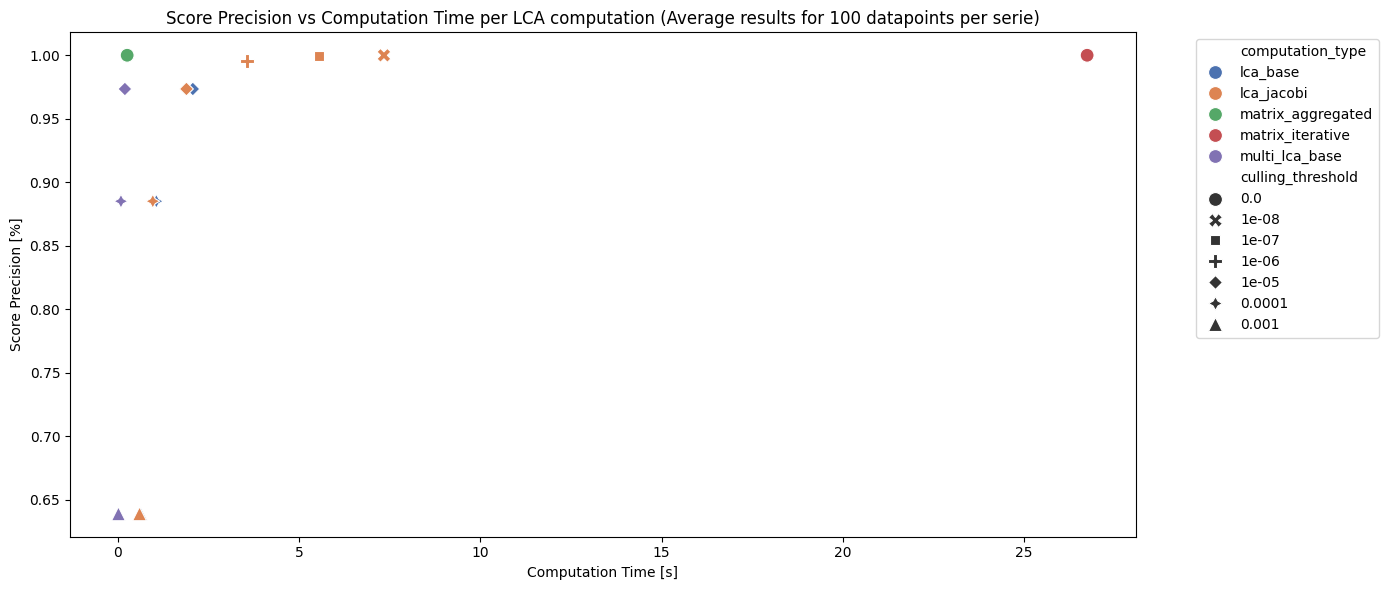

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
# Example: df = pd.read_csv("your_data.csv")

# Create the scatter plot
fig, (ax1) = plt.subplots(figsize=(14, 6))
scatter = sns.scatterplot(
    data=data_for_scatter_plot,
    x="computation_time",
    y="score_precision",
    hue="computation_type",  # Differentiate by color
    style="culling_threshold",  # Differentiate by shape
    palette="deep",  # Color palette for hue
    s=100,  # Size of the dots
    alpha=1,  # Transparency of the dots
    ax=ax1
)

# Add title and labels
ax1.set_title("Score Precision vs Computation Time per LCA computation (Average results for 100 datapoints per serie)")
ax1.set_xlabel("Computation Time [s]")
ax1.set_ylabel("Score Precision [%]")
#ax1.set_xscale("log")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# # Second plot
# sns.scatterplot(
#     data=data,
#     x="culling_threshold",
#     y="score_precision",
#     hue="computation_type",
#     palette="rocket",
#     s=100,
#     alpha=0.7,
#     ax=ax2,
# )
# ax2.set_title("Score Precision vs. Culling Threshold")
# ax2.set_xlabel("Culling Threshold")
# ax2.set_ylabel("Score Precision")
# ax2.set_xscale("log")
# ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

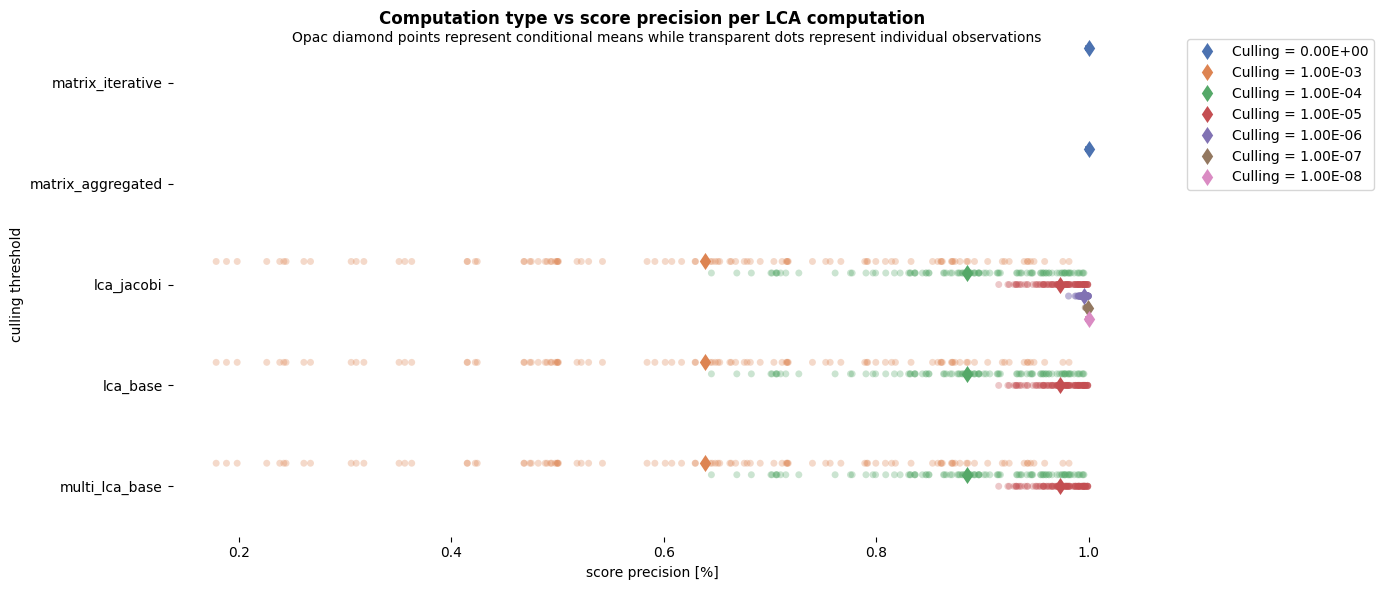

In [9]:
# Initialize the figure
f, ax1 = plt.subplots(figsize=(14, 6))
sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.stripplot(
    data=data, x="score_precision", y="computation_type", hue="culling_threshold_label",
    dodge=True, jitter=False, alpha=0.3, zorder=1, legend=False, palette="deep", ax=ax1
)

# Show the conditional means, aligning each pointplot in the
# center of the strips by adjusting the width allotted to each
# category (.8 by default) by the number of hue levels
sns.pointplot(
    data=data,  x="score_precision", y="computation_type", hue="culling_threshold_label", palette="deep", errorbar=None, dodge=0.8-0.8/7,
    markers="d", markersize=6, linestyle="none",ax=ax1,
)

ax1.set_title("Computation type vs score precision per LCA computation", weight="bold")
ax1.set_xlabel("score precision [%]")
ax1.set_ylabel("culling threshold")

ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.text(x=0.25, y=-0.4, s="Opac diamond points represent conditional means while transparent dots represent individual observations", fontsize=10)
# Show the plot
plt.tight_layout()
plt.show()

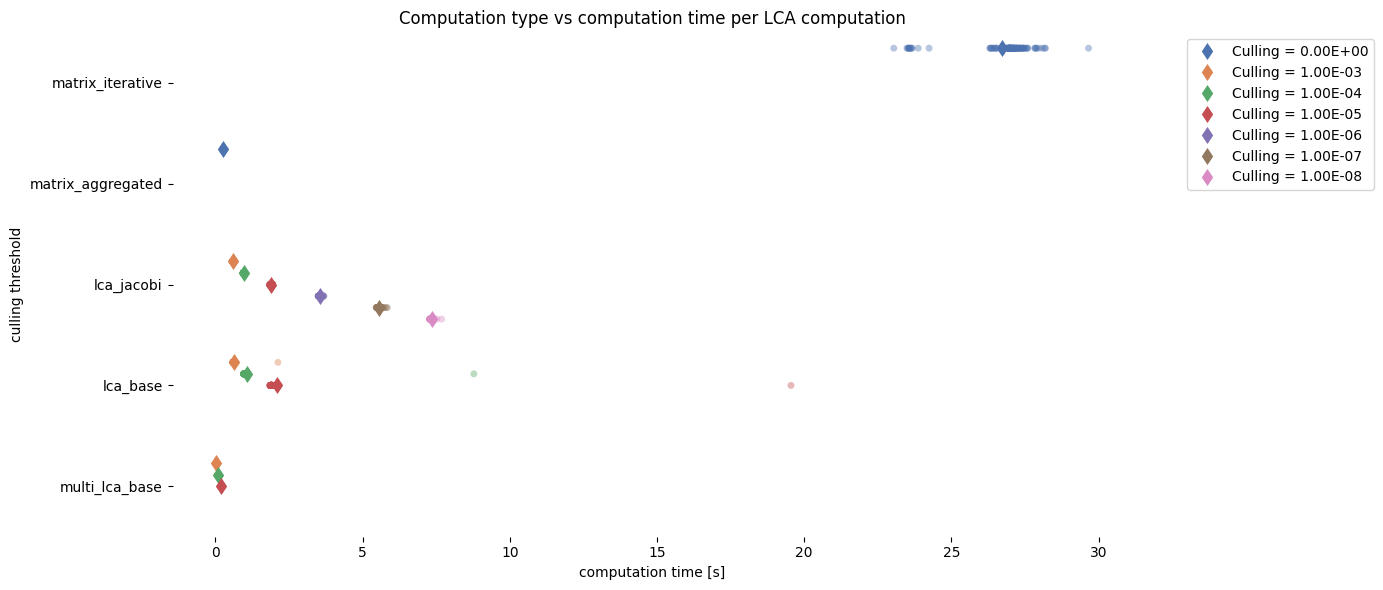

In [10]:
# Initialize the figure
f, ax1 = plt.subplots(figsize=(14, 6))
sns.despine(bottom=True, left=True)
# Show each observation with a scatterplot
sns.stripplot(
    data=data, x="computation_time", y="computation_type", hue="culling_threshold_label",
    dodge=True, jitter=False, alpha=0.4, zorder=1, legend=False, palette="deep",ax=ax1
)

# Show the conditional means, aligning each pointplot in the
# center of the strips by adjusting the width allotted to each
# category (.8 by default) by the number of hue levels
sns.pointplot(
    data=data,  x="computation_time", y="computation_type", hue="culling_threshold_label", palette="deep", errorbar=None, dodge=0.8-0.8/7,
    markers="d", markersize=6, linestyle="none",ax=ax1
)

ax1.set_title("Computation type vs computation time per LCA computation")
ax1.set_xlabel("computation time [s]")
ax1.set_ylabel("culling threshold")

ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# Show the plot
plt.tight_layout()
plt.show()

In [16]:
total_comp_time_data = data[["computation_type", "culling_threshold_label", "score_precision", "computation_time"]].groupby(["computation_type", "culling_threshold_label"], sort=False).agg({"computation_time":"sum", "score_precision":"mean"}).reset_index()
total_comp_time_data

,computation_type,culling_threshold_label,computation_time,score_precision
0,matrix_iterative,Culling = 0.00E+00,2673.606887,1.000000
1,matrix_aggregated,Culling = 0.00E+00,26.257460,1.000000
2,lca_jacobi,Culling = 1.00E-03,60.410042,0.639125
3,lca_jacobi,Culling = 1.00E-04,96.992132,0.885121
4,lca_jacobi,Culling = 1.00E-05,189.719144,0.973467
5,lca_jacobi,Culling = 1.00E-06,356.770802,0.995476
6,lca_jacobi,Culling = 1.00E-07,555.619216,0.999374
7,lca_jacobi,Culling = 1.00E-08,734.368403,0.999947
8,lca_base,Culling = 1.00E-03,63.276028,0.639118
9,lca_base,Culling = 1.00E-04,106.729684,0.885113


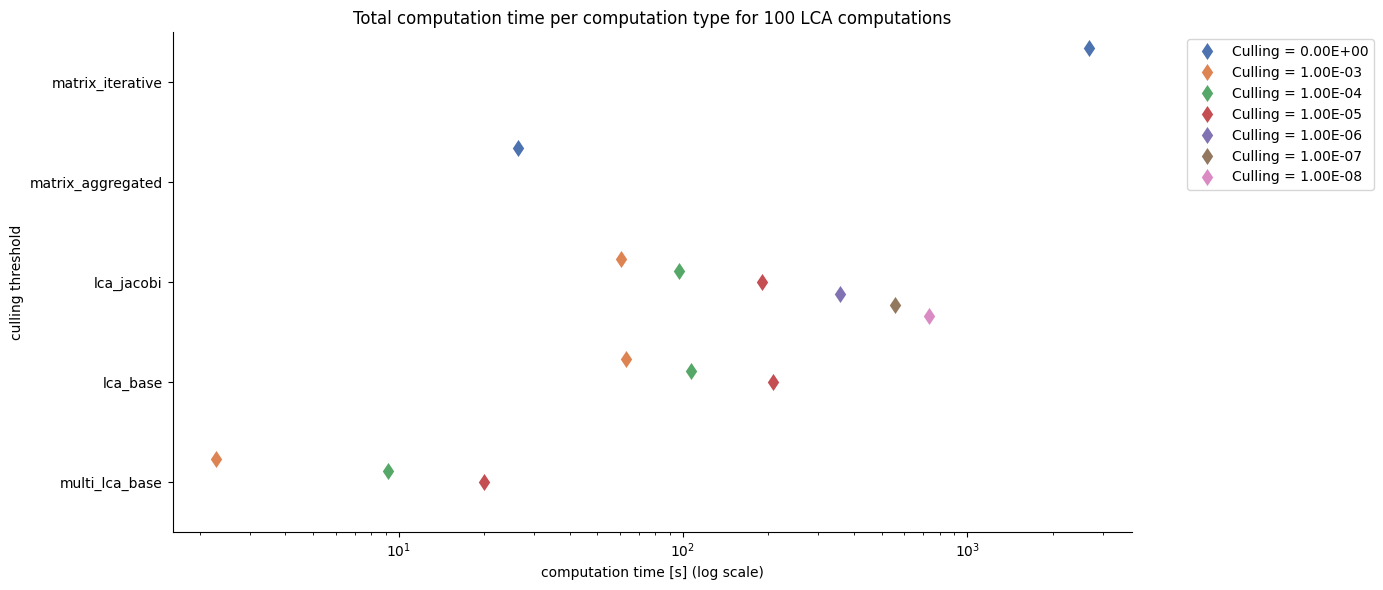

In [22]:
# Initialize the figure
f, ax1 = plt.subplots(figsize=(14, 6))
sns.despine()

# Show the conditional means, aligning each pointplot in the
# center of the strips by adjusting the width allotted to each
# category (.8 by default) by the number of hue levels
sns.pointplot(
    data=data,  x="computation_time", y="computation_type", hue="culling_threshold_label", palette="deep", errorbar=None, dodge=0.8-0.8/7,
    markers="d", markersize=6, linestyle="none",ax=ax1, estimator="sum"
)

ax1.set_title("Total computation time per computation type for 100 LCA computations")
ax1.set_xlabel("computation time [s] (log scale)")
ax1.set_ylabel("culling threshold")
ax1.set_xscale("log")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# Show the plot
plt.tight_layout()
plt.show()

In [12]:
data_for_cumulated_chart = data[["computation_type", "computation_time", "culling_threshold"]]
data_for_cumulated_chart = data_for_cumulated_chart[(data_for_cumulated_chart["culling_threshold"]==1e-5) | (data_for_cumulated_chart["culling_threshold"]==0)]
#data_for_cumulated_chart

data_for_cumulated_chart["cumulative_computation_time"] = data_for_cumulated_chart.groupby("computation_type")["computation_time"].cumsum()
#data_for_cumulated_chart
data_for_cumulated_chart["iteration"] = data_for_cumulated_chart.groupby("computation_type")["computation_type"].cumcount()+1
data_for_cumulated_chart

,computation_type,computation_time,culling_threshold,cumulative_computation_time,iteration
0,matrix_iterative,23.044163,0.00000,23.044163,1
1,matrix_iterative,23.596752,0.00000,46.640915,2
2,matrix_iterative,23.642661,0.00000,70.283575,3
3,matrix_iterative,23.529481,0.00000,93.813057,4
4,matrix_iterative,23.529631,0.00000,117.342688,5
...,...,...,...,...,...
1395,multi_lca_base,0.199860,0.00001,19.186602,96
1396,multi_lca_base,0.199860,0.00001,19.386462,97
1397,multi_lca_base,0.199860,0.00001,19.586323,98
1398,multi_lca_base,0.199860,0.00001,19.786183,99


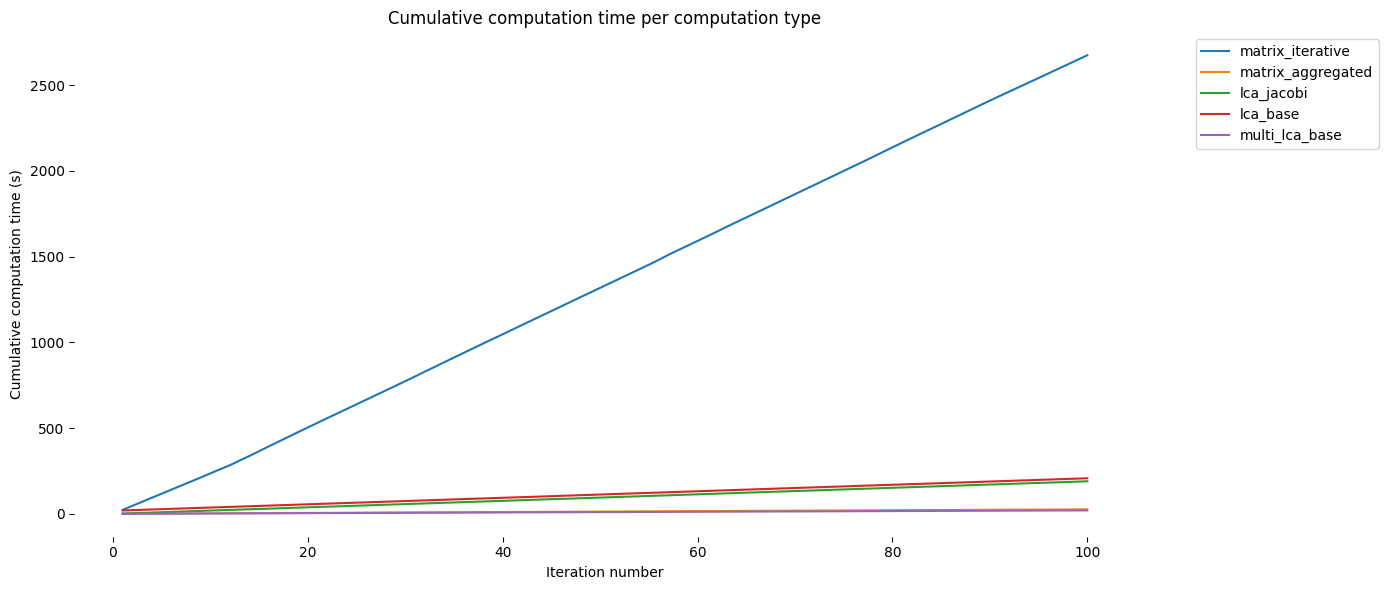

In [13]:
# Initialize the figure
f, ax1 = plt.subplots(figsize=(14, 6))
sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.lineplot(
    data=data_for_cumulated_chart, x="iteration", y="cumulative_computation_time", hue="computation_type",ax=ax1
)

# Show the conditional means, aligning each pointplot in the
# center of the strips by adjusting the width allotted to each
# category (.8 by default) by the number of hue levels


ax1.set_title("Cumulative computation time per computation type")
ax1.set_xlabel("Iteration number")
ax1.set_ylabel("Cumulative computation time (s)")

ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Show the plot
plt.tight_layout()
plt.show()